In [1]:
import pandas as pd

df = pd.read_csv('data/processed/la_features.csv', parse_dates=['Date Local'])

train = df[df['Date Local'].dt.year <= 2023]
test = df[df['Date Local'].dt.year == 2024]

features_to_drop = ['Date Local', 'AQI', 'pm25_aqi', 'ozone_aqi', 'ozone_dominant']

X_train = train.drop(columns=features_to_drop)
y_train = train['AQI']

X_test = test.drop(columns=features_to_drop)
y_test = test['AQI']

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 365
Test rows: 90


In [2]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

# TimeSeriesSplit on training data
tscv = TimeSeriesSplit(n_splits=4)

maes = []
for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05
    )
    
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val, preds)
    maes.append(mae)
    print(f"Fold MAE: {mae:.2f}")

print(f"\nAverage CV MAE: {np.mean(maes):.2f}")

Fold MAE: 9.56
Fold MAE: 8.72
Fold MAE: 10.12
Fold MAE: 8.40

Average CV MAE: 9.20


In [3]:
# Train final model on all training data
final_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05
)

final_model.fit(X_train, y_train)
test_preds = final_model.predict(X_test)
test_mae = mean_absolute_error(y_test, test_preds)

print(f"Test MAE (2024): {test_mae:.2f}")

Test MAE (2024): 5.56


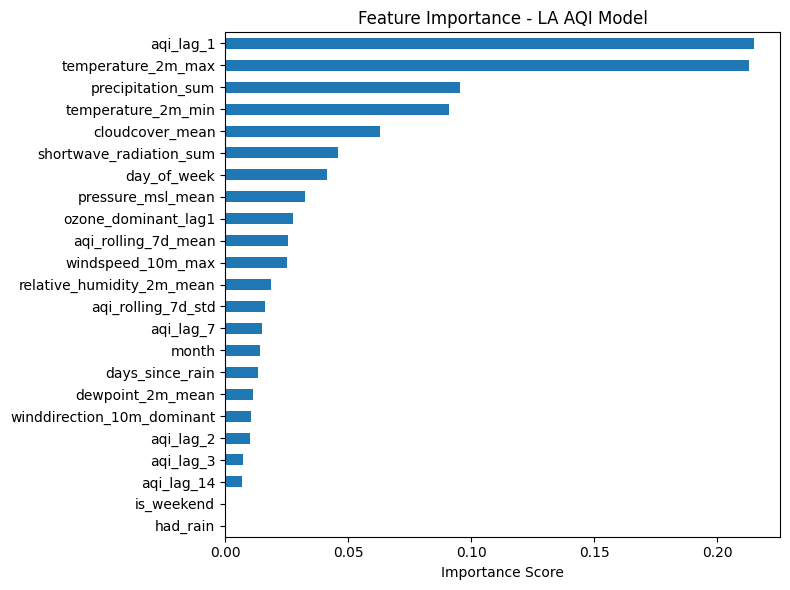

In [4]:
import matplotlib.pyplot as plt

importance = pd.Series(
    final_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

importance.plot(kind='barh', figsize=(8, 6))
plt.title('Feature Importance - LA AQI Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [5]:
import joblib
joblib.dump(final_model, 'models/la_xgboost.pkl')

['models/la_xgboost.pkl']

In [6]:
# Baseline numbers captured before adding ozone_dominant_lag1
baseline_cv_mae = 9.04
baseline_test_mae = 5.74

new_cv_mae = float(np.mean(maes))
new_test_mae = float(test_mae)

print(f"Baseline  (no ozone_dominant_lag1):  CV MAE {baseline_cv_mae:.2f} | Test MAE {baseline_test_mae:.2f}")
print(f"With ozone_dominant_lag1:            CV MAE {new_cv_mae:.2f} | Test MAE {new_test_mae:.2f}")
print(f"Delta:                                CV MAE {new_cv_mae - baseline_cv_mae:+.2f} | Test MAE {new_test_mae - baseline_test_mae:+.2f}")

Baseline  (no ozone_dominant_lag1):  CV MAE 9.04 | Test MAE 5.74
With ozone_dominant_lag1:            CV MAE 9.20 | Test MAE 5.56
Delta:                                CV MAE +0.16 | Test MAE -0.18
